In [1]:
# %%
import sys
import os
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, f1_score

import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="transformers"
)

# TabPFN Import
try:
    from tabpfn import TabPFNClassifier
    TABPFN_AVAILABLE = True
except ImportError:
    TABPFN_AVAILABLE = False

# Setup Path
def find_project_root(name='Bambino', start=None):
    if start is None: start = os.getcwd()
    parent = start
    while True:
        if os.path.basename(parent) == name: return parent
        if os.path.dirname(parent) == parent: return None
        parent = os.path.dirname(parent)

PROJECT_ROOT = find_project_root()
if PROJECT_ROOT: sys.path.append(PROJECT_ROOT)

import config_moment as cfg
import moment_utils
import eval_utils
from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
from config import settings as global_settings


In [2]:
# %% --- 1. Load Data & Extract Embeddings ---
print(">>> Step 1: Loading Data & Extracting MOMENT Embeddings")

extractor = moment_utils.MomentFeatureExtractor()

# Load Datasets
train_path = global_settings.get_dataset_path(cfg.dataset_type, global_settings.training_filename)
val_path = global_settings.get_dataset_path(cfg.dataset_type, global_settings.validation_filename)
test_path = global_settings.get_dataset_path(cfg.dataset_type, global_settings.test_filename)

train_ds = BoaOpenFaceDataset.load_dataset(train_path)
val_ds = BoaOpenFaceDataset.load_dataset(val_path)
test_ds = BoaOpenFaceDataset.load_dataset(test_path)

# Extract (Embeddings + Labels + Metadata)
X_train_emb, y_train, meta_train = extractor.extract(train_ds)
X_val_emb,   y_val,   meta_val   = extractor.extract(val_ds)
X_test_emb,  y_test,  meta_test  = extractor.extract(test_ds)

print(f"Embedding Shape: {X_train_emb.shape}")

>>> Step 1: Loading Data & Extracting MOMENT Embeddings
Loading MOMENT (embedding) on cuda...


/home/phd2/Scrivania/CorsoVenvs/BambinoVenv/lib/python3.11/site-packages/momentfm/models/moment.py:174: UserWarning: Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.
  warnings.warn("Only reconstruction head is pre-trained. Classification and forecasting heads must be fine-tuned.")


Extracting Embeddings (Batch Size 8)...


100%|██████████| 247/247 [03:01<00:00,  1.36it/s]


Extracting Embeddings (Batch Size 8)...


100%|██████████| 18/18 [00:12<00:00,  1.40it/s]


Extracting Embeddings (Batch Size 8)...


100%|██████████| 18/18 [00:12<00:00,  1.44it/s]

Embedding Shape: (1970, 1024)


In [3]:
# %% --- 2. Feature Fusion (Embeddings + Age + Sex) ---
print(">>> Step 2: Fusing Metadata")

scaler = StandardScaler()
# Normalize Age (Train fit, Val/Test transform)
age_train = scaler.fit_transform(meta_train[['age']].values)
age_val   = scaler.transform(meta_val[['age']].values)
age_test  = scaler.transform(meta_test[['age']].values)

# Encode Sex (Already 0/1 usually, ensure float/int)
sex_train = meta_train[['sex']].values.astype(float)
sex_val   = meta_val[['sex']].values.astype(float)
sex_test  = meta_test[['sex']].values.astype(float)

def fuse_features(emb, age, sex):
    return np.hstack([emb, age, sex])

X_train_full = fuse_features(X_train_emb, age_train, sex_train)
X_val_full   = fuse_features(X_val_emb,   age_val,   sex_val)
X_test_full  = fuse_features(X_test_emb,  age_test,  sex_test)

>>> Step 2: Fusing Metadata


In [4]:
# %% --- 3. Classifier Selection & Training ---
print(f">>> Step 3: Training Classifier ({cfg.model_type})")

# create a dict to map models with numbers
model_type_dict = {
    1: 'embeddings+histgb',
    2: 'pca+tabpfn',
    3: 'tabpfn',
    4: 'embeddings+mlp',
    5: 'embeddings+logreg'
}

# set model_type variable here
model_choice = 3  # Change this number to select a different model
model_type = model_type_dict.get(model_choice, "embeddings+histgb")

if model_type is not None:
    print(f"Warning: model_type variable '{model_type}' defined here, not in config file. Using model_type defined here.")
else:
    print(f"Using model_type from config: {cfg.model_type}")
    model_type = cfg.model_type

>>> Step 3: Training Classifier (embeddings+mlp)


In [5]:
# Output Setup
OUTPUT_DIR = Path(f"./results_{model_type}_{cfg.dataset_type}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

clf = None

def save_model(model, path):
    import joblib
    joblib.dump(model, path)
    print(f"Model saved to {path}")

if model_type == 'embeddings+histgb':
    # HistGradientBoosting (Robust, handles dense data well)
    clf = HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_depth=3,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        class_weight='balanced',
        random_state=cfg.seed
    )
    clf.fit(X_train_full, y_train)

    print("   -> HistGradientBoosting Training Complete.")
    save_model(clf, OUTPUT_DIR / "histgb_model.joblib")


elif model_type == 'pca+tabpfn':
    if not TABPFN_AVAILABLE:
        raise ImportError("TabPFN not installed! Run `pip install tabpfn`")
    
    print("   -> Applying PCA before TabPFN (TabPFN limit ~100 feats)")
    # Pipeline: PCA -> TabPFN
    # Note: TabPFN is small-data specialized (N < 2000). If N > 2000, consider bagging.
    clf = Pipeline([
        ('pca', PCA(n_components=100)), # Reduce 1024 -> 100
        ('tabpfn', TabPFNClassifier(device='cuda', n_estimators=32))
    ])
    clf.fit(X_train_full, y_train)

    print("   -> PCA + TabPFN Training Complete.")
    save_model(clf, OUTPUT_DIR / "pca_tabpfn_model.joblib")


elif model_type == "tabpfn":
    if not TABPFN_AVAILABLE:
        raise ImportError("TabPFN not installed! Run `pip install tabpfn`")
    
    print("   -> Using TabPFN without PCA (Ensure feature count is manageable)")
    clf = TabPFNClassifier(device='cuda', n_estimators=32)
    clf.fit(X_train_full, y_train)

    print("   -> TabPFN Training Complete.")
    save_model(clf, OUTPUT_DIR / "tabpfn_model.joblib")


elif model_type == 'embeddings+mlp':
    # Simple MLP
    clf = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=32,
        learning_rate='adaptive',
        max_iter=100,
        early_stopping=True,
        random_state=cfg.seed
    )
    clf.fit(X_train_full, y_train)

    print("   -> MLP Training Complete.")
    save_model(clf, OUTPUT_DIR / "mlp_model.joblib")


elif model_type == 'embeddings+logreg': 
    from sklearn.linear_model import LogisticRegression
    import warnings
    from sklearn.exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn.linear_model._sag")

    # Logistic Regression
    clf = LogisticRegression(
        max_iter=300,
        class_weight='balanced',
        random_state=cfg.seed,
        penalty='l2',
        solver='lbfgs',
    )
    clf.fit(X_train_full, y_train)

    print("   -> Logistic Regression Training Complete.")
    save_model(clf, OUTPUT_DIR / "logreg_model.joblib")

else:
    raise ValueError(f"Unknown model_type: {model_type}")


   -> Using TabPFN without PCA (Ensure feature count is manageable)
   -> TabPFN Training Complete.
Model saved to results_tabpfn_augmented_normalized/tabpfn_model.joblib


In [6]:
# %% --- 4. Evaluation ---
print(">>> Step 4: Evaluation")

# Optimize Threshold on Validation
probs_val = clf.predict_proba(X_val_full)[:, 1]
best_thr = 0.5
best_score = 0.0

for thr in np.linspace(0.1, 0.9, 50):
    preds = (probs_val >= thr).astype(int)
    score = balanced_accuracy_score(y_val, preds)
    if score > best_score:
        best_score = score
        best_thr = thr

print(f"Optimal Threshold (Val): {best_thr:.2f} (BalAcc: {best_score:.4f})")

# Final Test Prediction
probs_test = clf.predict_proba(X_test_full)[:, 1]
preds_test = (probs_test >= best_thr).astype(int)

# Use shared eval utility
eval_utils.evaluate_and_plot(
    y_true=y_test, 
    y_pred=preds_test, 
    y_probs=probs_test, 
    meta_df=meta_test, 
    output_dir=OUTPUT_DIR,
    model_name=f"MOMENT_{model_type}"
)

print("\n✅ Pipeline Completed Successfully.")

>>> Step 4: Evaluation
Optimal Threshold (Val): 0.62 (BalAcc: 0.6295)

--- MOMENT_tabpfn Final Results ---
Balanced Accuracy: 0.5020
MCC: 0.0039
Brier Score: 0.2099

Classification Report:
              precision    recall  f1-score   support

           0     0.2000    0.2222    0.2105        27
           1     0.8037    0.7818    0.7926       110

    accuracy                         0.6715       137
   macro avg     0.5019    0.5020    0.5016       137
weighted avg     0.6848    0.6715    0.6779       137

✅ Plots saved to results_tabpfn_augmented_normalized

✅ Pipeline Completed Successfully.


<Figure size 600x500 with 0 Axes>

## Boostrap on test

>>> Step 5: Bootstrap Analysis on Test Set (MOMENT)
Generating predictions for MOMENT_tabpfn on full test set...
Starting bootstrap (n=200) for MOMENT_tabpfn (Augmented: Yes)...
  Bootstrap iteration 20/200...
  Bootstrap iteration 40/200...
  Bootstrap iteration 60/200...
  Bootstrap iteration 80/200...
  Bootstrap iteration 100/200...
  Bootstrap iteration 120/200...
  Bootstrap iteration 140/200...
  Bootstrap iteration 160/200...
  Bootstrap iteration 180/200...
  Bootstrap iteration 200/200...
Bootstrap runs used: 200/200
Balanced Acc: mean=0.4996, 95% CI=(0.4006, 0.6210)
F1 Score:     mean=0.7937, 95% CI=(0.7180, 0.8659)
AUC:          mean=0.5140, 95% CI=(0.3788, 0.6734)
Specificity:  mean=0.2148, 95% CI=(0.0500, 0.4376)
Entry for MOMENT_tabpfn (Augmented: Yes) exists. Updating row.
Comparison results saved to /home/phd2/Scrivania/CorsoRepo/Bambino/paper_results/performance_comparison/performance_comparison.csv


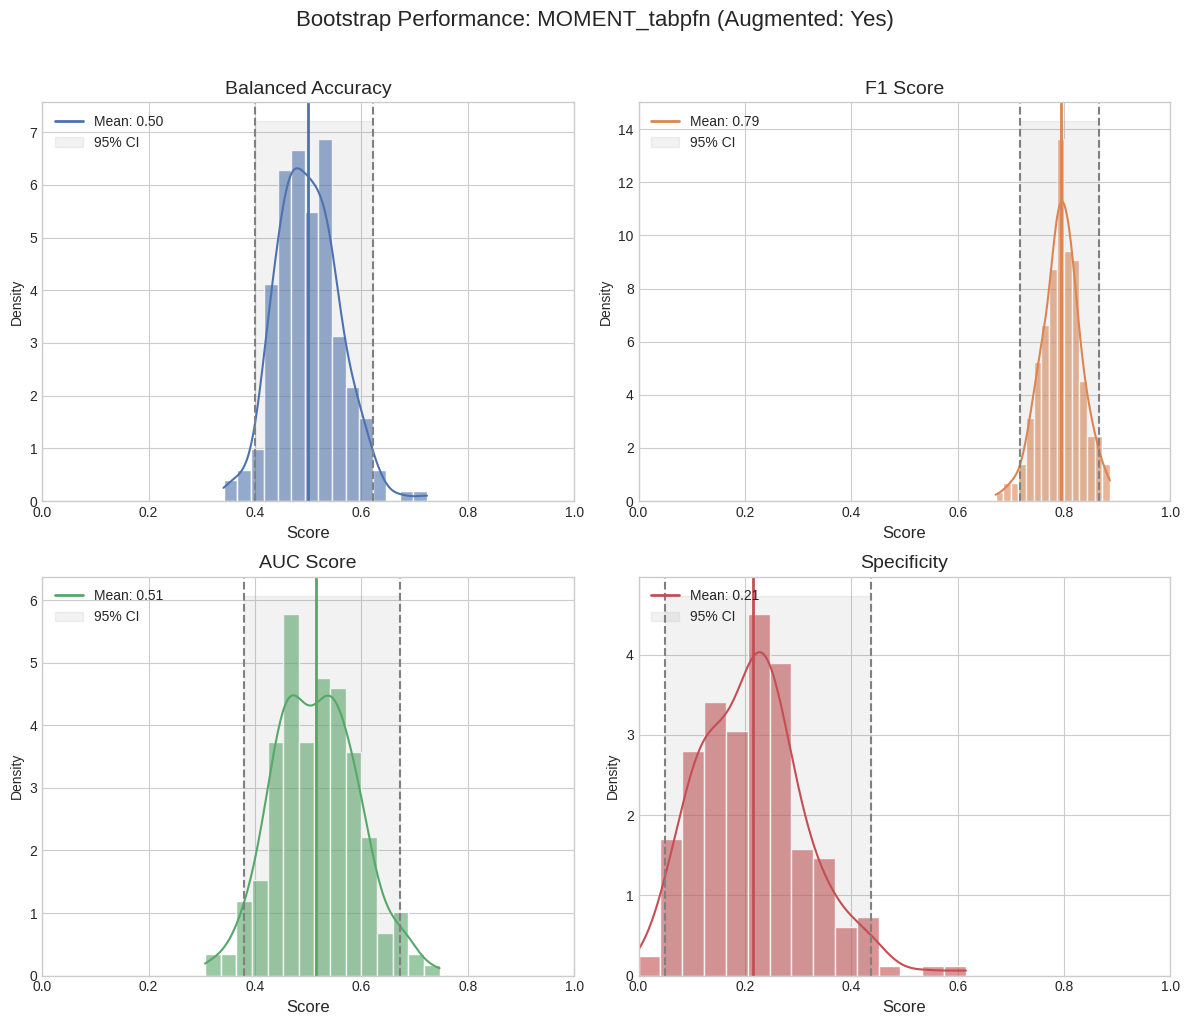

In [7]:
# %% --- 5. Bootstrap Analysis ---
print(">>> Step 5: Bootstrap Analysis on Test Set (MOMENT)")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score
import pandas as pd
import numpy as np

# --- CONFIGURATION ---
# Dynamically name the model based on current run variables
MODEL_NAME = f"MOMENT_{model_type}"
IS_AUGMENTED = "Yes" if "augmented" in cfg.dataset_type else "No"
RESULTS_CSV_PATH = Path("/home/phd2/Scrivania/CorsoRepo/Bambino/paper_results/performance_comparison/performance_comparison.csv")

# Parameters
n_boot = 200
frac = 0.70
N_test = len(y_test)
boot_size = max(1, int(round(frac * N_test)))

# --- OPTIMIZATION: PRE-CALCULATE PREDICTIONS ---
# We run inference once on the full test set. 
# Bootstrapping predictions is mathematically equivalent to bootstrapping inputs 
# for a fixed model, but 100x faster.

print(f"Generating predictions for {MODEL_NAME} on full test set...")

# Ensure we are in eval mode if clf is a PyTorch wrapper, otherwise sklearn handles it
if hasattr(clf, 'eval'): clf.eval() 

# Get probabilities for the positive class (1)
try:
    # Assuming clf is your MOMENT pipeline/classifier
    y_probs_all = clf.predict_proba(X_test_full)[:, 1]
except AttributeError:
    # Fallback if the model doesn't support predict_proba directly (e.g. raw pytorch)
    # You might need to adjust this depending on exactly what 'clf' is in your MOMENT script
    print("Warning: predict_proba failed, checking valid inputs...")
    y_probs_all = clf.predict(X_test_full) # Fallback to hard preds if necessary, though probas are preferred

y_true_all = np.array(y_test)

# --- BOOTSTRAP LOOP ---
rng = np.random.default_rng(42)
boot_bal_acc = []
boot_f1 = []
boot_auc = []
boot_specificity = []

print(f"Starting bootstrap (n={n_boot}) for {MODEL_NAME} (Augmented: {IS_AUGMENTED})...")

for i in range(n_boot):
    # Progress update every n_boot/10 iterations
    if (i+1) % (n_boot // 10) == 0:
        print(f"  Bootstrap iteration {i+1}/{n_boot}...")

    # Bootstrap indices
    idx = rng.choice(N_test, size=boot_size, replace=True)
    
    # Resample from PRE-CALCULATED arrays (Fast!)
    pb = y_probs_all[idx]
    yb = y_true_all[idx]

    # Guard: need at least 2 classes for ROC AUC usually
    if len(np.unique(yb)) < 2:
        continue

    # Calculate Metrics
    try:
        yhat = (pb >= best_thr).astype(int)

        boot_bal_acc.append(balanced_accuracy_score(yb, yhat))
        boot_f1.append(f1_score(yb, yhat, zero_division=0))
        boot_auc.append(roc_auc_score(yb, pb))

        # Specificity Calculation (TN / (TN + FP))
        cm = confusion_matrix(yb, yhat)
        
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        else:
            # Fallback for edge cases
            spec = np.nan 
        
        if not np.isnan(spec):
            boot_specificity.append(spec)

    except ValueError:
        continue

boot_res = pd.DataFrame({
    "balanced_accuracy": boot_bal_acc, 
    "f1": boot_f1, 
    "auc": boot_auc,
    "spec": boot_specificity
})

# Save Bootstrap raw results
# Ensure OUTPUT_DIR is defined or use RESULTS_CSV_PATH parent
out_dir = getattr(cfg, 'OUTPUT_DIR', RESULTS_CSV_PATH.parent) 
# Or if OUTPUT_DIR was defined earlier in your script, use that.
# Assuming standard variable:
if 'OUTPUT_DIR' in locals():
    out_dir = OUTPUT_DIR

boot_res.to_csv(out_dir / "bootstrap_test_metrics.csv", index=False)

# --- CI Calculation ---
def _ci(x, alpha=0.05):
    x = np.array(x)
    x = x[~np.isnan(x)]
    if len(x) == 0: return np.nan, np.nan
    lo, hi = np.percentile(x, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(lo), float(hi)

bal_mean = boot_res["balanced_accuracy"].mean()
bal_ci = _ci(boot_res["balanced_accuracy"])

f1_mean = boot_res["f1"].mean()
f1_ci = _ci(boot_res["f1"])

auc_mean = boot_res["auc"].mean()
auc_ci = _ci(boot_res["auc"])

spec_mean = boot_res["spec"].mean()
spec_ci = _ci(boot_res["spec"])

print(f"Bootstrap runs used: {len(boot_res)}/{n_boot}")
print(f"Balanced Acc: mean={bal_mean:.4f}, 95% CI=({bal_ci[0]:.4f}, {bal_ci[1]:.4f})")
print(f"F1 Score:     mean={f1_mean:.4f}, 95% CI=({f1_ci[0]:.4f}, {f1_ci[1]:.4f})")
print(f"AUC:          mean={auc_mean:.4f}, 95% CI=({auc_ci[0]:.4f}, {auc_ci[1]:.4f})")
print(f"Specificity:  mean={spec_mean:.4f}, 95% CI=({spec_ci[0]:.4f}, {spec_ci[1]:.4f})")

# --- SAVE TO COMPARISON CSV ---
new_row = {
    "model": MODEL_NAME,
    "augmented": IS_AUGMENTED,
    "bal_acc_mean": round(bal_mean, 4),
    "bal_acc_ci_low": round(bal_ci[0], 4),
    "bal_acc_ci_high": round(bal_ci[1], 4),
    "auc_mean": round(auc_mean, 4),
    "auc_ci_low": round(auc_ci[0], 4),
    "auc_ci_high": round(auc_ci[1], 4),
    "f1_mean": round(f1_mean, 4),
    "f1_ci_low": round(f1_ci[0], 4),
    "f1_ci_high": round(f1_ci[1], 4),
    "spec_mean": round(spec_mean, 4),
    "spec_ci_low": round(spec_ci[0], 4),
    "spec_ci_high": round(spec_ci[1], 4)
}

RESULTS_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)

if RESULTS_CSV_PATH.exists():
    df_results = pd.read_csv(RESULTS_CSV_PATH)
    # Ensure columns exist
    if "spec_mean" not in df_results.columns:
        df_results["spec_mean"] = np.nan
        df_results["spec_ci_low"] = np.nan
        df_results["spec_ci_high"] = np.nan

    mask = (df_results["model"] == MODEL_NAME) & (df_results["augmented"] == IS_AUGMENTED)
    if mask.any():
        print(f"Entry for {MODEL_NAME} (Augmented: {IS_AUGMENTED}) exists. Updating row.")
        for col, val in new_row.items():
            df_results.loc[mask, col] = val
    else:
        print(f"Appending new result.")
        df_results = pd.concat([df_results, pd.DataFrame([new_row])], ignore_index=True)
else:
    print(f"Creating new results file.")
    df_results = pd.DataFrame([new_row])

df_results.to_csv(RESULTS_CSV_PATH, index=False)
print(f"Comparison results saved to {RESULTS_CSV_PATH}")

# --- PLOTTING ---
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

# Fixed Colors list (added 4th color for Specificity)
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
metrics_list = [
    ("balanced_accuracy", "Balanced Accuracy", bal_mean, bal_ci, colors[0]),
    ("f1", "F1 Score", f1_mean, f1_ci, colors[1]),
    ("auc", "AUC Score", auc_mean, auc_ci, colors[2]),
    ("spec", "Specificity", spec_mean, spec_ci, colors[3])
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
fig.suptitle(f"Bootstrap Performance: {MODEL_NAME} (Augmented: {IS_AUGMENTED})", fontsize=16, y=1.02)

for ax, (col, title, mean_val, ci_val, color) in zip(axes, metrics_list):
    data = boot_res[col].dropna()
    sns.histplot(data, bins=15, kde=True, ax=ax, color=color, edgecolor='white', alpha=0.6, stat="density")
    ax.axvline(mean_val, color=color, linestyle='-', linewidth=2, label=f'Mean: {mean_val:.2f}')
    ax.axvline(ci_val[0], color='gray', linestyle='--', linewidth=1.5)
    ax.axvline(ci_val[1], color='gray', linestyle='--', linewidth=1.5)
    ymin, ymax = ax.get_ylim()
    ax.fill_betweenx([ymin, ymax], ci_val[0], ci_val[1], color='gray', alpha=0.1, label='95% CI')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Score", fontsize=12)
    ax.set_xlim(0, 1)
    ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(out_dir / "bootstrap_test_distributions.png", dpi=300, bbox_inches="tight")
plt.show()